In [ ]:
#@title Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [ ]:
#@title Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
#@title Variables
BATCH_SIZE = 32

# Teacher model variables
FINETUNE_EPOCHS = 10
TEACHER_LR = 0.001
TEACHER_OPTIMIZER = torch.optim.Adam
TEACHER_LOSS = torch.nn.CrossEntropyLoss()

# Student model variables
EMBED_DIM = 64
NUM_ATTN_HEADS = 4
NUM_TRANSFORMER_BLOCKS = 4
# Assuming 7*7 patches ...so total 4*4 = 16 patches

In [ ]:
#@title Dataset

# Define a transformation to convert MNIST images to 3 channels
transform_3_channel = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0)==1 else x) # Convert 1-channel to 3-channel
])

# Download and load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform_3_channel,
    download=True
)

# Download and load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform_3_channel,
    download=True
)

# Create data loaders for training and testing
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Batch size: {BATCH_SIZE}")

# Example of one batch
for images, labels in train_loader:
    print(f"Shape of one batch of images: {images.shape}")
    print(f"Shape of one batch of labels: {labels.shape}")
    break

Number of training samples: 60000
Number of test samples: 10000
Batch size: 32
Shape of one batch of images: torch.Size([32, 3, 28, 28])
Shape of one batch of labels: torch.Size([32])


In [ ]:
#@title Teacher Model (ResNet)

teacher_model = torchvision.models.get_model("resnet34", weights = "DEFAULT")
# print(teacher_model)

In [ ]:
#@title Modifying Teacher Model
for param in teacher_model.parameters():
  param.requires_grad = False

teacher_model.fc = torch.nn.Linear(teacher_model.fc.in_features, 10)

for param in teacher_model.fc.parameters():
  param.requires_grad = True

teacher_model = teacher_model.to(device)

In [ ]:
#@title Finetuning Teacher Model
optimizer = TEACHER_OPTIMIZER(teacher_model.parameters(), lr=TEACHER_LR)
criterion = TEACHER_LOSS

for epoch in range(FINETUNE_EPOCHS):
  print(f"Epoch {epoch+1}/{FINETUNE_EPOCHS}")
  curr_loss = 0
  teacher_model.train()
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = teacher_model(images)
    loss = criterion(outputs, labels)
    curr_loss += loss.item()
    loss.backward()
    optimizer.step()

  curr_loss /= len(train_loader)

  print("Training loss = ", curr_loss)

for param in teacher_model.parameters():
  param.requires_grad = False

Epoch 1/10
Training loss =  0.8774149130662282
Epoch 2/10
Training loss =  0.7293606055577596
Epoch 3/10
Training loss =  0.7097058426062266
Epoch 4/10
Training loss =  0.7014385267734528
Epoch 5/10
Training loss =  0.701845394953092
Epoch 6/10
Training loss =  0.6930222112735113
Epoch 7/10
Training loss =  0.6975758831421535
Epoch 8/10
Training loss =  0.6964816656668981
Epoch 9/10
Training loss =  0.6892000187397003
Epoch 10/10
Training loss =  0.7039885985374451


In [ ]:
teacher_model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = teacher_model(images)
    for i in range(len(outputs)):
      if torch.argmax(outputs[i]) == labels[i]:
        correct += 1
        total += 1
      else:
        total += 1

  print("Teacher Model Accuracy = ", correct/total)

Teacher Model Accuracy =  0.8008


In [ ]:
#@title Student Model

# Components
# Patch Embedding: image -> patch token
# Transformer Blocks
# DeiT block
#   # predictions of teacher
#   # predictions of <CLS>
#   # predictions of <Distil>
#   # ground truth
#   # Cross-entropy Loss
#   # KL divergence Loss

In [ ]:
#@title Patch Embedding

class PatchEmbedding(nn.Module):
  def __init__(self, embed_dim = EMBED_DIM):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=5, stride=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1)

  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = F.max_pool2d(x, kernel_size=2, stride=2)
    x = F.relu(self.conv2(x))
    x = F.max_pool2d(x, kernel_size=2, stride=2)
    x = x.flatten(2)
    x = x.permute(0,2,1)
    x = x.contiguous()
    return x

In [ ]:
patch_embedding = PatchEmbedding(EMBED_DIM).to(device)
images, labels = next(iter(train_loader))
images = images.to(device)
print(images.shape)
print("**********")
res = patch_embedding(images)
print(res.shape)

torch.Size([32, 3, 28, 28])
**********
torch.Size([32, 16, 64])


In [ ]:
#@title Transformer Block
class TransformerBlock(nn.Module):
  def __init__(self, embed_dim = EMBED_DIM, num_heads = NUM_ATTN_HEADS):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embed_dim)
    self.MHA = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
    self.layer_norm2 = nn.LayerNorm(embed_dim)
    self.MLP = nn.Sequential(nn.Linear(embed_dim, embed_dim*4),
                             nn.ReLU(),
                             nn.Linear(embed_dim*4, embed_dim))

  def forward(self, x):
    x_residual = x
    x = self.layer_norm1(x)
    x, _ = self.MHA(x, x, x)
    x += x_residual

    x_residual = x
    x = self.layer_norm2(x)
    x = self.MLP(x)
    x += x_residual

    return x

In [ ]:
transformer_block = TransformerBlock(EMBED_DIM, NUM_ATTN_HEADS).to(device)
res2 = transformer_block(res)
print(res2.shape)

torch.Size([32, 16, 64])


In [ ]:
# @title Student Model
# Make things like patch size generalizable

class StudentModel(nn.Module):
  def __init__(self, embed_dim = EMBED_DIM, num_heads = NUM_ATTN_HEADS, num_transformer_blocks = NUM_TRANSFORMER_BLOCKS):
    super().__init__()
    self.patch_embedding = PatchEmbedding(embed_dim)
    self.cls_token = nn.Parameter(torch.randn(1, embed_dim))
    self.distil_token = nn.Parameter(torch.randn(1, embed_dim))
    self.pos_embedding = nn.Parameter(torch.randn(1, 18, embed_dim))

    self.transformer_blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(num_transformer_blocks)])
    self.layer_norm_cls = nn.LayerNorm(embed_dim)
    self.layer_norm_distil = nn.LayerNorm(embed_dim)
    self.fc_cls = nn.Linear(embed_dim, 10)
    self.fc_distil = nn.Linear(embed_dim, 10)

  def forward(self, x):
    x = self.patch_embedding(x)
    cls_token = self.cls_token.repeat(x.shape[0], 1, 1)
    distil_token = self.distil_token.repeat(x.shape[0], 1, 1)
    x = torch.cat([cls_token, x, distil_token], dim=1)
    x += self.pos_embedding
    for block in self.transformer_blocks:
      x = block(x)

    x_cls = self.layer_norm_cls(x[:, 0, :])
    x_distil = self.layer_norm_distil(x[:, -1, :])

    x_cls = self.fc_cls(x_cls)
    x_distil = self.fc_distil(x_distil)

    return x_cls, x_distil

In [ ]:
student_model = StudentModel(EMBED_DIM, NUM_ATTN_HEADS, NUM_TRANSFORMER_BLOCKS).to(device)
images, labels = next(iter(train_loader))
images = images.to(device)
print(images.shape)
res_cls, res_distil = student_model(images)
print("Res CLS: ", res_cls.shape)
print("Res Distil: ", res_distil.shape)

torch.Size([32, 3, 28, 28])
Res CLS:  torch.Size([32, 10])
Res Distil:  torch.Size([32, 10])


In [ ]:
# #@title DeiT Implementation

# class DeiT(nn.Module):
#   def __init__(self, teacher_model = teacher_model):
#     super().__init__()
#     self.teacher_model = teacher_model

In [ ]:
# @title Training student model using knowledge distilation

teacher_model = teacher_model.to(device)
student_model = StudentModel().to(device)

#supervised loss
criterion_supervised = nn.CrossEntropyLoss()
#distillation loss
criterion_distillation = nn.KLDivLoss(reduction='batchmean')

NUM_EPOCHS = 10
LR = 0.001
ALPHA = 0.5 # Weightage param for Supervised and Distillation Loss

optimizer = torch.optim.Adam(student_model.parameters(), lr=LR)

In [ ]:
for epoch in range(NUM_EPOCHS):
  print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

  student_model.train()
  teacher_model.eval()

  total_loss = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    cls_pred, distil_pred = student_model(images)

    optimizer.zero_grad()

    with torch.no_grad():
      teacher_pred = teacher_model(images)

    loss_supervised = criterion_supervised(cls_pred, labels)
    loss_distillation = criterion_distillation(F.log_softmax(distil_pred, dim = 1),
                                               F.softmax(teacher_pred, dim = 1))

    loss = ALPHA*loss_supervised + (1-ALPHA)*loss_distillation
    total_loss += loss.item()

    loss.backward()
    optimizer.step()

  total_loss /= len(train_loader)
  print("Training loss = ", total_loss)
  print("***************************")

Epoch 1/10
Training loss =  0.3663840970913569
***************************
Epoch 2/10
Training loss =  0.23498891005118688
***************************
Epoch 3/10
Training loss =  0.22014970393578212
***************************
Epoch 4/10
Training loss =  0.2110350221157074
***************************
Epoch 5/10
Training loss =  0.20458714224497476
***************************
Epoch 6/10
Training loss =  0.1982980586528778
***************************
Epoch 7/10
Training loss =  0.19338426410357157
***************************
Epoch 8/10
Training loss =  0.18997132706244788
***************************
Epoch 9/10
Training loss =  0.18555891350507736
***************************
Epoch 10/10
Training loss =  0.1809061000943184
***************************


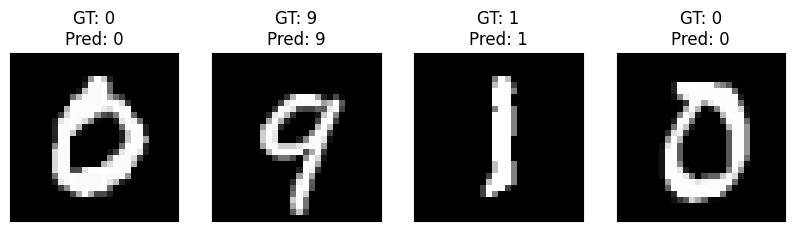

In [ ]:
#@title Inference (with visualization)
import random

student_model.eval()
with torch.no_grad():
    # Get a batch of test data
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # Move images to device
    images = images.to(device)
    labels = labels.to(device)

    # Get predictions from the student model
    cls_outputs, distil_outputs = student_model(images)
    # Average the predictions from cls and distil tokens
    averaged_outputs = (cls_outputs + distil_outputs) / 2
    _, predicted = torch.max(averaged_outputs, 1)

    # Select 4 random images from the batch
    num_images_to_show = 4
    indices = random.sample(range(len(images)), num_images_to_show)

    fig = plt.figure(figsize=(10, 5))
    for i, idx in enumerate(indices):
        ax = fig.add_subplot(1, num_images_to_show, i + 1, xticks=[], yticks=[])
        # MNIST images are 1 channel, but transformed to 3. Matplotlib expects (H,W,C)
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Normalize for display
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f"GT: {labels[idx].item()}\nPred: {predicted[idx].item()}")
    plt.show()

In [ ]:
#@title Accuracy check
total_count = 0
correct_count = 0
for images, labels in test_loader:
  images = images.to(device)
  labels = labels.to(device)
  cls_outputs, distil_outputs = student_model(images)
  averaged_outputs = (cls_outputs + distil_outputs)/2
  for i in range(len(averaged_outputs)):
    total_count += 1
    if (torch.argmax(averaged_outputs[i]) == labels[i]):
      correct_count += 1

accuracy = correct_count/total_count
print("Accuracy = ", accuracy*100, "%")

Accuracy =  99.09 %
